In [ ]:
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import ReduceLROnPlateau
from pathlib import Path

# ─── Imports depuis src ──────────────────────────────────
from src.data.data_loader import get_loaders, BINARY_CLASSES, TUMOR_CLASSES, SEED
from src.model.model import SimpleCNN, build_model_a, build_model_b, count_params
from src.model.train_utils import set_seed, Train_Val, train_model
from src.utils.helpers import (plot_history, plot_curves,
                                evaluate_model, evaluate_model_scratch)

# ─── Config ─────────
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_DIR  = Path('models')
MODEL_DIR.mkdir(exist_ok=True)

MODEL_A_PATH = MODEL_DIR / 'model_a_binary.pth'
MODEL_B_PATH = MODEL_DIR / 'model_b_3class.pth'

LR       = 1e-4
PATIENCE = 5
EPOCHS_A = 12
EPOCHS_B = 25

print(f'Device : {DEVICE}')

Device : cpu


[Dataset: binary]
  Train :  4856 images
  Val   :   856 images
  Test  :  1311 images
Model A scratch — 946,430 paramètres
 Epoch  train_loss   train_acc    val_loss     val_acc          LR


c:\Users\nour\miniconda3\envs\cnn\lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   1/17  train_loss=0.3970  train_acc=0.834  val_loss=0.2029  val_acc=0.933  lr=0.000300  ✓ saved
Epoch   2/17  train_loss=0.1785  train_acc=0.938  val_loss=0.1212  val_acc=0.958  lr=0.000300  ✓ saved
Epoch   3/17  train_loss=0.1499  train_acc=0.948  val_loss=0.0937  val_acc=0.964  lr=0.000300  ✓ saved
Epoch   4/17  train_loss=0.1253  train_acc=0.958  val_loss=0.0713  val_acc=0.979  lr=0.000300  ✓ saved
Epoch   5/17  train_loss=0.1134  train_acc=0.964  val_loss=0.1070  val_acc=0.952  lr=0.000300
Epoch   6/17  train_loss=0.0986  train_acc=0.966  val_loss=0.0635  val_acc=0.978  lr=0.000300  ✓ saved
Epoch   7/17  train_loss=0.0955  train_acc=0.969  val_loss=0.0646  val_acc=0.979  lr=0.000300
Epoch   8/17  train_loss=0.0920  train_acc=0.968  val_loss=0.0615  val_acc=0.978  lr=0.000300  ✓ saved
Epoch   9/17  train_loss=0.0874  train_acc=0.974  val_loss=0.0606  val_acc=0.981  lr=0.000300  ✓ saved
Epoch  10/17  train_loss=0.0880  train_acc=0.972  val_loss=0.0722  val_acc=0.977  lr=0.0003

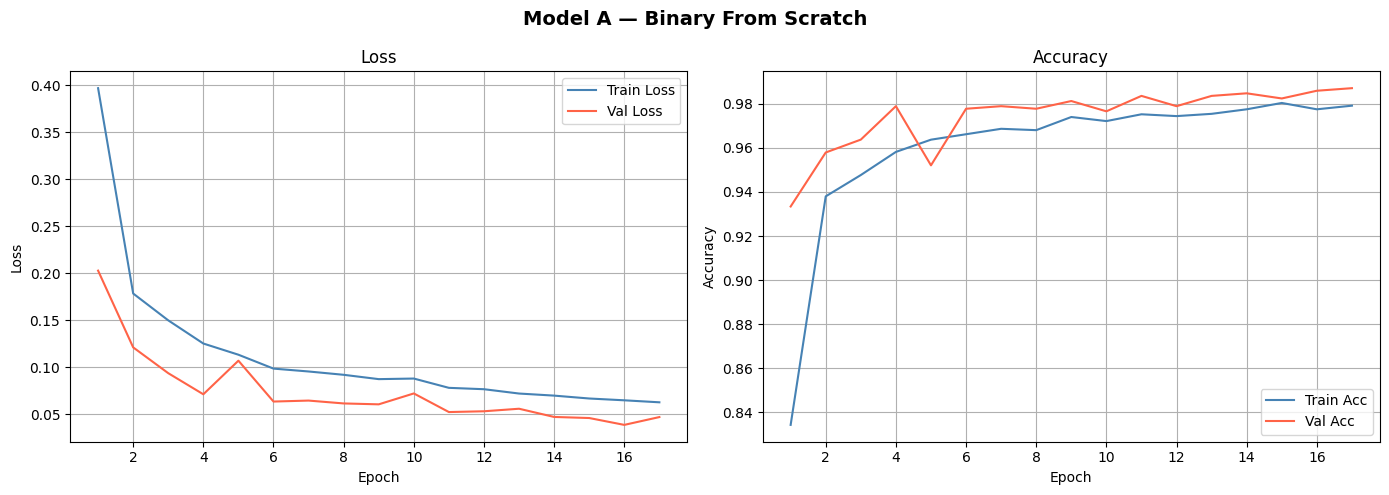

In [2]:
set_seed(SEED)

train_loader_a, val_loader_a, test_loader_a = get_loaders('binary')

params_model_a = {
    "shape_in":        (3, 224, 224),
    "initial_filters": 8,
    "num_fc1":         100,
    "dropout_rate":    0.5,
    "num_classes":     2
}

model_scratch_a = SimpleCNN(params_model_a).to(DEVICE)
print(f"Model A scratch — {count_params(model_scratch_a):,} paramètres")

opt_a = torch.optim.Adam(model_scratch_a.parameters(), lr=3e-4, weight_decay=1e-4)

params_train_a = {
    "train":       train_loader_a,
    "val":         val_loader_a,
    "epochs":      17,
    "optimiser":   opt_a,
    "lr_change":   ReduceLROnPlateau(opt_a, mode='min', factor=0.5, patience=5),
    "f_loss":      nn.NLLLoss(reduction="sum"),
    "weight_path": "weights_scratch_a.pt",
    "patience":    5,
}

model_scratch_a, loss_hist_a, metric_hist_a = Train_Val(model_scratch_a, params_train_a)
plot_curves(loss_hist_a, metric_hist_a, title="Model A — Binary From Scratch")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\nour/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:02<00:00, 6.07MB/s]



  Training Model A - Binary MobileNet
  Device: cpu
Epoch   1/12  train_loss=0.0913  train_acc=0.971  val_loss=0.0264  val_acc=0.993  ✓ saved
Epoch   2/12  train_loss=0.0410  train_acc=0.988  val_loss=0.0255  val_acc=0.993  ✓ saved
Epoch   3/12  train_loss=0.0227  train_acc=0.993  val_loss=0.0275  val_acc=0.991
Epoch   4/12  train_loss=0.0141  train_acc=0.995  val_loss=0.0209  val_acc=0.994  ✓ saved
Epoch   5/12  train_loss=0.0163  train_acc=0.995  val_loss=0.0176  val_acc=0.995  ✓ saved
Epoch   6/12  train_loss=0.0099  train_acc=0.996  val_loss=0.0261  val_acc=0.995
Epoch   7/12  train_loss=0.0126  train_acc=0.996  val_loss=0.0244  val_acc=0.993
Epoch   8/12  train_loss=0.0093  train_acc=0.997  val_loss=0.0203  val_acc=0.996
Epoch   9/12  train_loss=0.0056  train_acc=0.997  val_loss=0.0200  val_acc=0.994
Epoch  10/12  train_loss=0.0057  train_acc=0.998  val_loss=0.0128  val_acc=0.996  ✓ saved
Epoch  11/12  train_loss=0.0036  train_acc=0.999  val_loss=0.0193  val_acc=0.994
Epoch  12/1

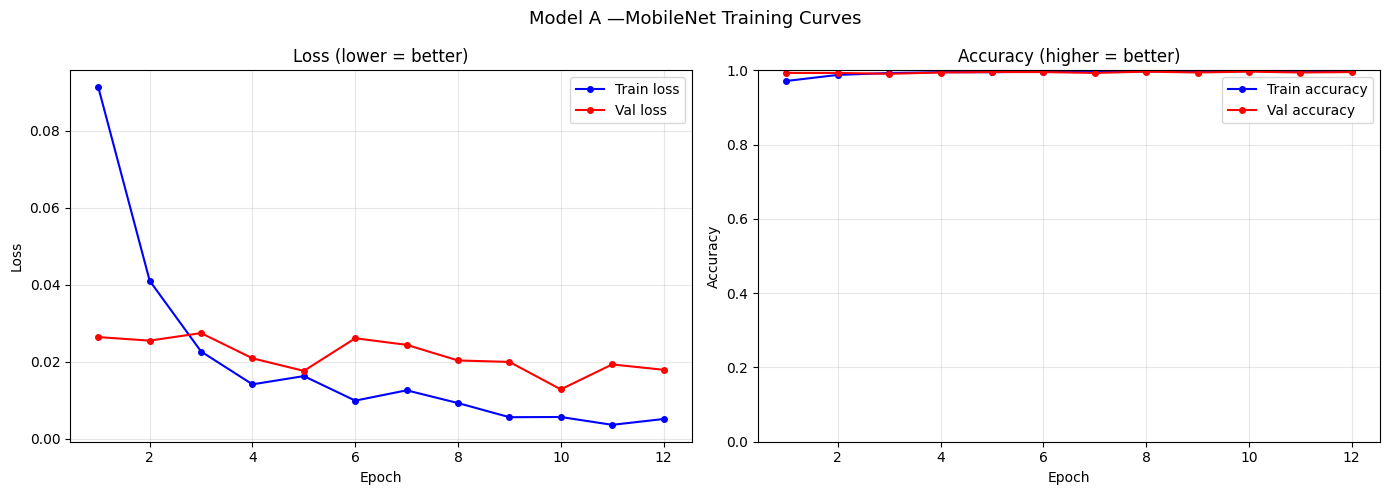

In [3]:
set_seed(SEED)

model_a   = build_model_a()
history_a = train_model(
    model        = model_a,
    train_loader = train_loader_a,
    val_loader   = val_loader_a,
    epochs       = EPOCHS_A,
    save_path    = MODEL_A_PATH,
    model_name   = 'Model A - Binary MobileNet',
    DEVICE       = DEVICE,
    LR           = LR,
    PATIENCE     = PATIENCE
)
plot_history(history_a, 'Model A —MobileNet Training Curves')

[Dataset: 3class]
  Train :  3500 images
  Val   :   617 images
  Test  :   906 images

  Training Model B — 3-class ResNet
  Device: cpu
Epoch   1/25  train_loss=0.3414  train_acc=0.868  val_loss=0.1443  val_acc=0.943  ✓ saved
Epoch   2/25  train_loss=0.1370  train_acc=0.947  val_loss=0.1094  val_acc=0.966  ✓ saved
Epoch   3/25  train_loss=0.1120  train_acc=0.961  val_loss=0.0885  val_acc=0.969  ✓ saved
Epoch   4/25  train_loss=0.0746  train_acc=0.977  val_loss=0.0871  val_acc=0.971  ✓ saved
Epoch   5/25  train_loss=0.0920  train_acc=0.969  val_loss=0.0633  val_acc=0.984  ✓ saved
Epoch   6/25  train_loss=0.0474  train_acc=0.985  val_loss=0.0907  val_acc=0.972
Epoch   7/25  train_loss=0.0595  train_acc=0.980  val_loss=0.0656  val_acc=0.976
Epoch   8/25  train_loss=0.0543  train_acc=0.982  val_loss=0.0627  val_acc=0.981  ✓ saved
Epoch   9/25  train_loss=0.0427  train_acc=0.983  val_loss=0.1601  val_acc=0.943
Epoch  10/25  train_loss=0.0402  train_acc=0.986  val_loss=0.0650  val_acc=0.97

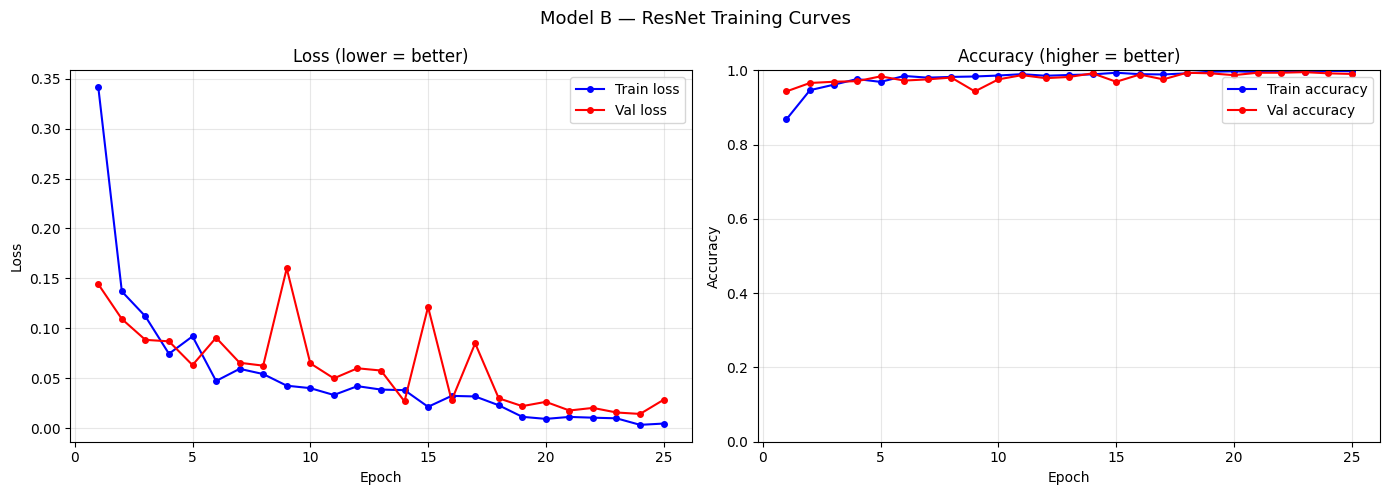

In [4]:
set_seed(SEED)

train_loader_b, val_loader_b, test_loader_b = get_loaders('3class')

model_b   = build_model_b()
history_b = train_model(
    model        = model_b,
    train_loader = train_loader_b,
    val_loader   = val_loader_b,
    epochs       = EPOCHS_B,
    save_path    = MODEL_B_PATH,
    model_name   = 'Model B — 3-class ResNet',
    DEVICE       = DEVICE,
    LR           = LR,
    PATIENCE     = PATIENCE
)
plot_history(history_b, 'Model B — ResNet Training Curves')


  Model A Scratch — Threshold=0.4
              precision    recall  f1-score   support

     notumor       0.93      0.97      0.95       405
       tumor       0.99      0.97      0.98       906

    accuracy                           0.97      1311
   macro avg       0.96      0.97      0.96      1311
weighted avg       0.97      0.97      0.97      1311



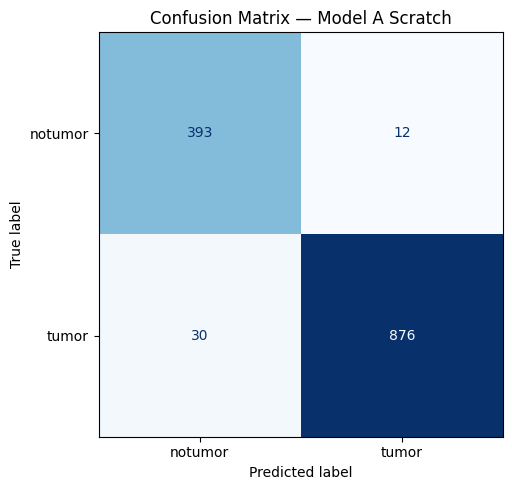

c:\Users\nour\miniconda3\envs\cnn\lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



  Model A MobileNet  — Test Results
              precision    recall  f1-score   support

     notumor       1.00      1.00      1.00       405
       tumor       1.00      1.00      1.00       906

    accuracy                           1.00      1311
   macro avg       1.00      1.00      1.00      1311
weighted avg       1.00      1.00      1.00      1311



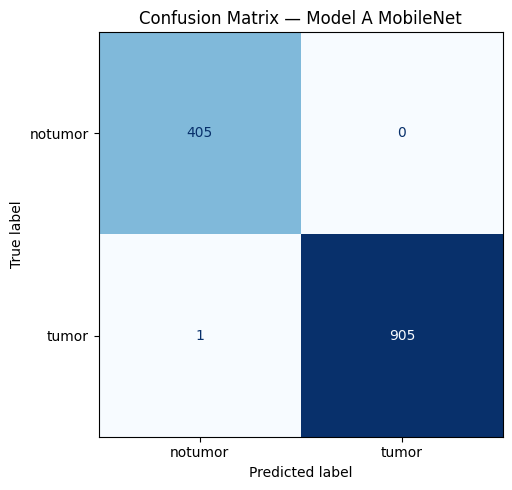

c:\Users\nour\miniconda3\envs\cnn\lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



  Model B ResNet  — Test Results
              precision    recall  f1-score   support

      glioma       1.00      0.99      0.99       300
  meningioma       0.99      1.00      0.99       306
   pituitary       1.00      1.00      1.00       300

    accuracy                           1.00       906
   macro avg       1.00      1.00      1.00       906
weighted avg       1.00      1.00      1.00       906



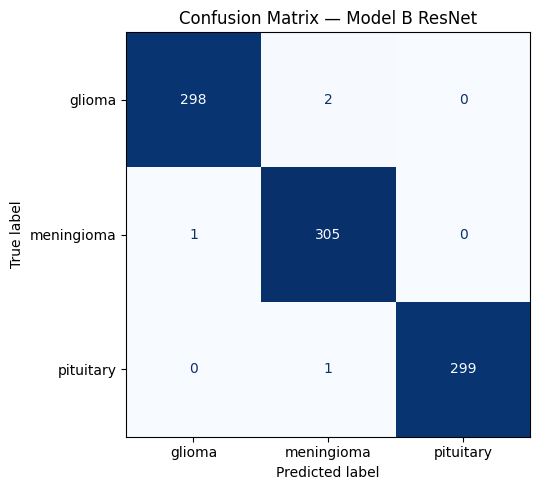

In [5]:
# Model A scratch
evaluate_model_scratch(
    model_scratch_a, test_loader_a,
    BINARY_CLASSES, 'Model A Scratch',
    DEVICE, threshold=0.4
)

# Model A MobileNet
evaluate_model(
    model_a, test_loader_a,
    BINARY_CLASSES, 'Model A MobileNet',
    DEVICE, MODEL_A_PATH, MODEL_B_PATH
)

# Model B ResNet
evaluate_model(
    model_b, test_loader_b,
    TUMOR_CLASSES, 'Model B ResNet',
    DEVICE, MODEL_A_PATH, MODEL_B_PATH
)